Task 3 -- CycleGAN Image Style Transfer (Monet <-> Photo).
Author: Ishan Shah

Architecture (own design):
  - Generator: ResNet-style encoder-residual-decoder (6 residual blocks), InstanceNorm2d,
    reflection padding -- the architecture used in the original CycleGAN paper.
  - Discriminator: 70x70 PatchGAN, InstanceNorm2d, LeakyReLU.
  - Adversarial loss: LSGAN (MSE), lambda_cycle=10, lambda_identity=5.
  - A 50-image replay buffer stabilizes discriminator training (as in the CycleGAN paper).
  - Own independent data subsample: 300 Monet paintings + 300 photos (seed 42) from the
    shared monet_jpg/photo_jpg pools, at 128x128 resolution.

In [1]:
import glob
import itertools
import json
import os
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

C:\Users\<user>\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Config

In [2]:
SEED = 42
IMG_SIZE = 128
N_MONET = 300
N_PHOTO = 300
N_TEST = 40
BATCH_SIZE = 4
EPOCHS = 40
LR = 2e-4
LAMBDA_CYCLE = 10.0
LAMBDA_IDENTITY = 5.0
DECAY_START_EPOCH = 20  # linear LR decay to 0 over the second half

if os.environ.get("SMOKE_TEST") == "1":  # fast correctness check for reproducibility grading
    N_MONET, N_PHOTO, N_TEST, EPOCHS, DECAY_START_EPOCH = 20, 20, 8, 2, 1

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)
if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

try:
    HERE = os.path.dirname(os.path.abspath(__file__))
except NameError:
    HERE = os.path.abspath(".")
MEMBER_DIR = os.path.dirname(HERE)
DATA_DIR = os.path.join(MEMBER_DIR, "..", "data")
CKPT_DIR = os.path.join(MEMBER_DIR, "checkpoints")
OUT_DIR = os.path.join(MEMBER_DIR, "outputs")
os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(os.path.join(OUT_DIR, "pred_A2B"), exist_ok=True)
os.makedirs(os.path.join(OUT_DIR, "pred_B2A"), exist_ok=True)

Device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


### 3.1 Data: two unpaired image domains

In [3]:
monet_files = sorted(glob.glob(os.path.join(DATA_DIR, "monet_jpg", "*.jpg")))
photo_files = sorted(glob.glob(os.path.join(DATA_DIR, "photo_jpg", "*.jpg")))
monet_test_files = sorted(glob.glob(os.path.join(DATA_DIR, "monet_jpg_test", "*.jpg")))
photo_test_files = sorted(glob.glob(os.path.join(DATA_DIR, "photo_jpg_test", "*.jpg")))

rng = random.Random(SEED)
monet_sample = rng.sample(monet_files, min(N_MONET, len(monet_files)))
photo_sample = rng.sample(photo_files, min(N_PHOTO, len(photo_files)))
monet_test_sample = rng.sample(monet_test_files, min(N_TEST, len(monet_test_files)))
photo_test_sample = rng.sample(photo_test_files, min(N_TEST, len(photo_test_files)))
print(f"Monet train/test: {len(monet_sample)}/{len(monet_test_sample)} | "
      f"Photo train/test: {len(photo_sample)}/{len(photo_test_sample)}")

transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize([0.5] * 3, [0.5] * 3),
])
eval_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize([0.5] * 3, [0.5] * 3),
])


class UnpairedDataset(Dataset):
    def __init__(self, files_a, files_b, transform):
        self.files_a = files_a
        self.files_b = files_b
        self.transform = transform

    def __len__(self):
        return max(len(self.files_a), len(self.files_b))

    def __getitem__(self, idx):
        a = Image.open(self.files_a[idx % len(self.files_a)]).convert("RGB")
        b = Image.open(self.files_b[random.randint(0, len(self.files_b) - 1)]).convert("RGB")
        return self.transform(a), self.transform(b)


train_ds = UnpairedDataset(monet_sample, photo_sample, transform)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)


def load_eval_batch(files, transform, n):
    imgs = [transform(Image.open(f).convert("RGB")) for f in files[:n]]
    return torch.stack(imgs)

Monet train/test: 300/40 | Photo train/test: 300/40


### 3.1 CycleGAN architecture: ResNet generator + PatchGAN discriminator

In [4]:
class ResidualBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.block = nn.Sequential(
            nn.ReflectionPad2d(1),
            nn.Conv2d(dim, dim, 3),
            nn.InstanceNorm2d(dim),
            nn.ReLU(inplace=True),
            nn.ReflectionPad2d(1),
            nn.Conv2d(dim, dim, 3),
            nn.InstanceNorm2d(dim),
        )

    def forward(self, x):
        return x + self.block(x)


class ResNetGenerator(nn.Module):
    def __init__(self, n_residual=6, ngf=64):
        super().__init__()
        layers = [
            nn.ReflectionPad2d(3),
            nn.Conv2d(3, ngf, 7),
            nn.InstanceNorm2d(ngf),
            nn.ReLU(inplace=True),
        ]
        in_ch = ngf
        for _ in range(2):  # downsample x2
            out_ch = in_ch * 2
            layers += [
                nn.Conv2d(in_ch, out_ch, 3, stride=2, padding=1),
                nn.InstanceNorm2d(out_ch),
                nn.ReLU(inplace=True),
            ]
            in_ch = out_ch
        for _ in range(n_residual):
            layers.append(ResidualBlock(in_ch))
        for _ in range(2):  # upsample x2
            out_ch = in_ch // 2
            layers += [
                nn.ConvTranspose2d(in_ch, out_ch, 3, stride=2, padding=1, output_padding=1),
                nn.InstanceNorm2d(out_ch),
                nn.ReLU(inplace=True),
            ]
            in_ch = out_ch
        layers += [nn.ReflectionPad2d(3), nn.Conv2d(in_ch, 3, 7), nn.Tanh()]
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)


class PatchGANDiscriminator(nn.Module):
    def __init__(self, ndf=64):
        super().__init__()
        def block(in_ch, out_ch, norm=True, stride=2):
            layers = [nn.Conv2d(in_ch, out_ch, 4, stride=stride, padding=1)]
            if norm:
                layers.append(nn.InstanceNorm2d(out_ch))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers

        self.model = nn.Sequential(
            *block(3, ndf, norm=False),
            *block(ndf, ndf * 2),
            *block(ndf * 2, ndf * 4),
            *block(ndf * 4, ndf * 8, stride=1),
            nn.Conv2d(ndf * 8, 1, 4, stride=1, padding=1),
        )

    def forward(self, x):
        return self.model(x)


class ReplayBuffer:
    """50-image history buffer for discriminator stability (CycleGAN trick)."""

    def __init__(self, max_size=50):
        self.max_size = max_size
        self.data = []

    def push_and_pop(self, images):
        result = []
        for img in images:
            img = img.unsqueeze(0)
            if len(self.data) < self.max_size:
                self.data.append(img)
                result.append(img)
            elif random.random() > 0.5:
                idx = random.randint(0, self.max_size - 1)
                result.append(self.data[idx].clone())
                self.data[idx] = img
            else:
                result.append(img)
        return torch.cat(result, dim=0)


G_AB = ResNetGenerator().to(device)  # monet -> photo
G_BA = ResNetGenerator().to(device)  # photo -> monet
D_A = PatchGANDiscriminator().to(device)  # discriminates monet domain
D_B = PatchGANDiscriminator().to(device)  # discriminates photo domain

n_params_total = sum(p.numel() for net in [G_AB, G_BA, D_A, D_B] for p in net.parameters())
print(f"Total parameter count (2 generators + 2 discriminators): {n_params_total:,}")

opt_G = torch.optim.Adam(itertools.chain(G_AB.parameters(), G_BA.parameters()), lr=LR, betas=(0.5, 0.999))
opt_D_A = torch.optim.Adam(D_A.parameters(), lr=LR, betas=(0.5, 0.999))
opt_D_B = torch.optim.Adam(D_B.parameters(), lr=LR, betas=(0.5, 0.999))

def lr_lambda(epoch):
    if epoch < DECAY_START_EPOCH:
        return 1.0
    return max(0.0, 1.0 - (epoch - DECAY_START_EPOCH) / (EPOCHS - DECAY_START_EPOCH))

sched_G = torch.optim.lr_scheduler.LambdaLR(opt_G, lr_lambda)
sched_D_A = torch.optim.lr_scheduler.LambdaLR(opt_D_A, lr_lambda)
sched_D_B = torch.optim.lr_scheduler.LambdaLR(opt_D_B, lr_lambda)

mse = nn.MSELoss()
l1 = nn.L1Loss()
buffer_fake_A = ReplayBuffer()
buffer_fake_B = ReplayBuffer()

Total parameter count (2 generators + 2 discriminators): 21,204,872


### 3.1 / 3.1.3 Training with adversarial + cycle-consistency (+ identity) loss

In [5]:
history = {"epoch": [], "loss_G": [], "loss_D": [], "loss_cycle": [], "loss_identity": [], "grad_norm_G": []}
nan_count = 0
log_path = os.path.join(MEMBER_DIR, "raw_train_log.txt")
log_f = open(log_path, "w")

if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()

t_start = time.time()
n_images_processed = 0
for epoch in range(1, EPOCHS + 1):
    ep_loss_G, ep_loss_D, ep_loss_cycle, ep_loss_id, ep_grad = 0.0, 0.0, 0.0, 0.0, 0.0
    n_batches = 0
    for real_A, real_B in train_loader:  # A = monet, B = photo
        real_A, real_B = real_A.to(device), real_B.to(device)
        valid = torch.ones((real_A.size(0), 1, 14, 14), device=device)
        fake_label = torch.zeros((real_A.size(0), 1, 14, 14), device=device)

        # ---- Generators ----
        opt_G.zero_grad()
        id_A = G_BA(real_A)  # identity: monet through photo->monet should stay monet
        id_B = G_AB(real_B)
        loss_identity = (l1(id_A, real_A) + l1(id_B, real_B)) / 2

        fake_B = G_AB(real_A)
        fake_A = G_BA(real_B)
        pred_fake_B = D_B(fake_B)
        pred_fake_A = D_A(fake_A)
        loss_gan = (mse(pred_fake_B, valid[:, :, :pred_fake_B.shape[2], :pred_fake_B.shape[3]]) +
                    mse(pred_fake_A, valid[:, :, :pred_fake_A.shape[2], :pred_fake_A.shape[3]])) / 2

        rec_A = G_BA(fake_B)
        rec_B = G_AB(fake_A)
        loss_cycle = (l1(rec_A, real_A) + l1(rec_B, real_B)) / 2

        loss_G = loss_gan + LAMBDA_CYCLE * loss_cycle + LAMBDA_IDENTITY * loss_identity
        loss_G.backward()
        grad_norm = sum(p.grad.data.norm(2).item() ** 2 for p in itertools.chain(G_AB.parameters(), G_BA.parameters()) if p.grad is not None) ** 0.5
        opt_G.step()

        if torch.isnan(loss_G):
            nan_count += 1

        # ---- Discriminator A (monet) ----
        opt_D_A.zero_grad()
        pred_real = D_A(real_A)
        fake_A_ = buffer_fake_A.push_and_pop(fake_A.detach())
        pred_fake = D_A(fake_A_)
        v = valid[:, :, :pred_real.shape[2], :pred_real.shape[3]]
        f = fake_label[:, :, :pred_fake.shape[2], :pred_fake.shape[3]]
        loss_D_A = (mse(pred_real, v) + mse(pred_fake, f)) / 2
        loss_D_A.backward()
        opt_D_A.step()

        # ---- Discriminator B (photo) ----
        opt_D_B.zero_grad()
        pred_real = D_B(real_B)
        fake_B_ = buffer_fake_B.push_and_pop(fake_B.detach())
        pred_fake = D_B(fake_B_)
        v = valid[:, :, :pred_real.shape[2], :pred_real.shape[3]]
        f = fake_label[:, :, :pred_fake.shape[2], :pred_fake.shape[3]]
        loss_D_B = (mse(pred_real, v) + mse(pred_fake, f)) / 2
        loss_D_B.backward()
        opt_D_B.step()

        ep_loss_G += loss_G.item()
        ep_loss_D += (loss_D_A.item() + loss_D_B.item()) / 2
        ep_loss_cycle += loss_cycle.item()
        ep_loss_id += loss_identity.item()
        ep_grad += grad_norm
        n_batches += 1
        n_images_processed += real_A.size(0) * 2

    sched_G.step(); sched_D_A.step(); sched_D_B.step()
    history["epoch"].append(epoch)
    history["loss_G"].append(ep_loss_G / n_batches)
    history["loss_D"].append(ep_loss_D / n_batches)
    history["loss_cycle"].append(ep_loss_cycle / n_batches)
    history["loss_identity"].append(ep_loss_id / n_batches)
    history["grad_norm_G"].append(ep_grad / n_batches)

    line = (f"epoch {epoch:3d}/{EPOCHS} | loss_G {history['loss_G'][-1]:.4f} | "
            f"loss_D {history['loss_D'][-1]:.4f} | cycle {history['loss_cycle'][-1]:.4f} | "
            f"identity {history['loss_identity'][-1]:.4f} | grad_norm_G {history['grad_norm_G'][-1]:.3f}")
    print(line)
    log_f.write(line + "\n")
    log_f.flush()

train_time_sec = time.time() - t_start
images_per_sec = n_images_processed / train_time_sec
peak_mem_mb = (torch.cuda.max_memory_allocated() / 1e6) if torch.cuda.is_available() else 0.0
log_f.write(f"\nTotal training time: {train_time_sec:.2f}s | images/sec: {images_per_sec:.2f} | "
            f"peak_mem_MB: {peak_mem_mb:.1f} | nan_count: {nan_count}\n")
log_f.close()

torch.save(G_AB.state_dict(), os.path.join(CKPT_DIR, "G_AB.pt"))
torch.save(G_BA.state_dict(), os.path.join(CKPT_DIR, "G_BA.pt"))
torch.save(D_A.state_dict(), os.path.join(CKPT_DIR, "D_A.pt"))
torch.save(D_B.state_dict(), os.path.join(CKPT_DIR, "D_B.pt"))

with open(os.path.join(OUT_DIR, "history.json"), "w") as f:
    json.dump(history, f, indent=2)

epoch   1/40 | loss_G 5.1871 | loss_D 0.3302 | cycle 0.3252 | identity 0.3079 | grad_norm_G 30.064


epoch   2/40 | loss_G 4.3037 | loss_D 0.2351 | cycle 0.2684 | identity 0.2473 | grad_norm_G 26.983


epoch   3/40 | loss_G 4.2197 | loss_D 0.2131 | cycle 0.2597 | identity 0.2400 | grad_norm_G 25.904


epoch   4/40 | loss_G 4.1617 | loss_D 0.2014 | cycle 0.2576 | identity 0.2314 | grad_norm_G 27.875


epoch   5/40 | loss_G 4.1025 | loss_D 0.1896 | cycle 0.2507 | identity 0.2283 | grad_norm_G 26.312


...

epoch  36/40 | loss_G 2.4595 | loss_D 0.1104 | cycle 0.1303 | identity 0.1311 | grad_norm_G 16.804


epoch  37/40 | loss_G 2.4630 | loss_D 0.1129 | cycle 0.1290 | identity 0.1311 | grad_norm_G 16.942


epoch  38/40 | loss_G 2.3934 | loss_D 0.1062 | cycle 0.1231 | identity 0.1273 | grad_norm_G 15.510


epoch  39/40 | loss_G 2.3735 | loss_D 0.1093 | cycle 0.1220 | identity 0.1254 | grad_norm_G 15.351


epoch  40/40 | loss_G 2.3147 | loss_D 0.1165 | cycle 0.1185 | identity 0.1241 | grad_norm_G 13.880


### Loss curves

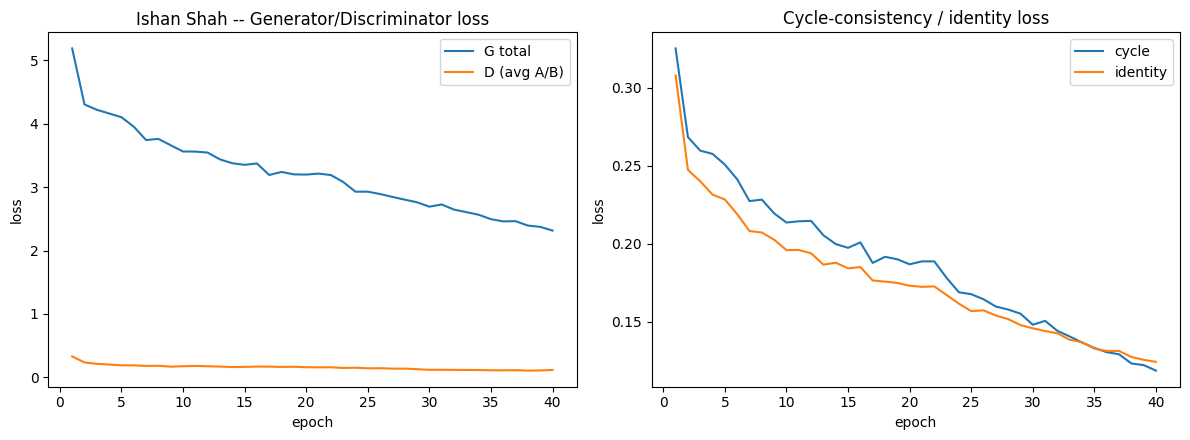

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(history["epoch"], history["loss_G"], label="G total")
axes[0].plot(history["epoch"], history["loss_D"], label="D (avg A/B)")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss"); axes[0].legend()
axes[0].set_title("Ishan Shah -- Generator/Discriminator loss")
axes[1].plot(history["epoch"], history["loss_cycle"], label="cycle")
axes[1].plot(history["epoch"], history["loss_identity"], label="identity")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("loss"); axes[1].legend()
axes[1].set_title("Cycle-consistency / identity loss")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "loss_curves.png"), dpi=130)
plt.show()

### 3.2 Evaluation: generate translations on the held-out test images

In [7]:
G_AB.eval(); G_BA.eval()
real_A_test = load_eval_batch(monet_test_sample, eval_transform, N_TEST).to(device)
real_B_test = load_eval_batch(photo_test_sample, eval_transform, N_TEST).to(device)

with torch.no_grad():
    t0 = time.time()
    fake_B_test = G_AB(real_A_test)   # monet -> photo
    fake_A_test = G_BA(real_B_test)   # photo -> monet
    gen_time = time.time() - t0
    rec_A_test = G_BA(fake_B_test)    # cycle: monet -> photo -> monet
    rec_B_test = G_AB(fake_A_test)    # cycle: photo -> monet -> photo

gen_images_per_sec = (real_A_test.size(0) + real_B_test.size(0)) / gen_time


def save_grid(tensor_batch, path, n=8):
    imgs = ((tensor_batch[:n].clamp(-1, 1) + 1) / 2 * 255).byte().cpu().permute(0, 2, 3, 1).numpy()
    fig, axes = plt.subplots(1, n, figsize=(2 * n, 2))
    for i, ax in enumerate(axes):
        ax.imshow(imgs[i])
        ax.axis("off")
    plt.tight_layout()
    plt.savefig(path, dpi=110)
    plt.close()


save_grid(fake_B_test, os.path.join(OUT_DIR, "pred_A2B", "sample_grid.png"))
save_grid(fake_A_test, os.path.join(OUT_DIR, "pred_B2A", "sample_grid.png"))

# Save individual translated images (for the pred_A2B / pred_B2A folders)
def save_individual(tensor_batch, out_folder, prefix):
    imgs = ((tensor_batch.clamp(-1, 1) + 1) / 2 * 255).byte().cpu().permute(0, 2, 3, 1).numpy()
    for i, img in enumerate(imgs):
        Image.fromarray(img).save(os.path.join(out_folder, f"{prefix}_{i:03d}.jpg"))


save_individual(fake_B_test, os.path.join(OUT_DIR, "pred_A2B"), "monet2photo")
save_individual(fake_A_test, os.path.join(OUT_DIR, "pred_B2A"), "photo2monet")

### Full metrics: FID/KID (both directions), cycle L1, LPIPS, content-preservation cosine sim

In [8]:
import sys
COMMON_DIR = os.path.abspath(os.path.join(MEMBER_DIR, "..", "..", "common"))
sys.path.insert(0, COMMON_DIR)
from eval_gan import compute_fid_kid, cycle_reconstruction_l1, ContentFeatureExtractor, lpips_distance  # noqa: E402

fid_kid_A2B = compute_fid_kid(real_B_test, fake_B_test, device=device)  # fake photos vs real photos
fid_kid_B2A = compute_fid_kid(real_A_test, fake_A_test, device=device)  # fake monets vs real monets

cycle_l1_A = cycle_reconstruction_l1(real_A_test, rec_A_test)
cycle_l1_B = cycle_reconstruction_l1(real_B_test, rec_B_test)

content_extractor = ContentFeatureExtractor(device=device)
content_sim_A2B = content_extractor.cosine_similarity(real_A_test, fake_B_test)
content_sim_B2A = content_extractor.cosine_similarity(real_B_test, fake_A_test)

lpips_A2B = lpips_distance(real_A_test, fake_B_test, device=device)
lpips_B2A = lpips_distance(real_B_test, fake_A_test, device=device)

final_metrics = {
    "member": "Ishan Shah",
    "architecture": "ResNet generator (6 resblocks, InstanceNorm) + 70x70 PatchGAN, LSGAN loss",
    "img_size": IMG_SIZE, "epochs": EPOCHS, "batch_size": BATCH_SIZE,
    "lambda_cycle": LAMBDA_CYCLE, "lambda_identity": LAMBDA_IDENTITY,
    "n_train_monet": len(monet_sample), "n_train_photo": len(photo_sample),
    "fid_monet2photo": fid_kid_A2B["fid"], "kid_monet2photo_mean": fid_kid_A2B["kid_mean"], "kid_monet2photo_std": fid_kid_A2B["kid_std"],
    "fid_photo2monet": fid_kid_B2A["fid"], "kid_photo2monet_mean": fid_kid_B2A["kid_mean"], "kid_photo2monet_std": fid_kid_B2A["kid_std"],
    "cycle_l1_monet": cycle_l1_A, "cycle_l1_photo": cycle_l1_B,
    "lpips_monet2photo": lpips_A2B, "lpips_photo2monet": lpips_B2A,
    "content_cosine_sim_monet2photo": content_sim_A2B, "content_cosine_sim_photo2monet": content_sim_B2A,
    "final_loss_G": history["loss_G"][-1], "final_loss_D": history["loss_D"][-1],
    "final_loss_cycle": history["loss_cycle"][-1], "final_loss_identity": history["loss_identity"][-1],
    "grad_norm_G_mean": float(np.mean(history["grad_norm_G"])), "grad_norm_G_max": float(np.max(history["grad_norm_G"])),
    "nan_count": nan_count,
    "param_count_total": n_params_total,
    "training_time_sec": train_time_sec, "train_images_per_sec": images_per_sec,
    "gen_images_per_sec": gen_images_per_sec,
    "peak_memory_MB": peak_mem_mb,
}

import csv
with open(os.path.join(MEMBER_DIR, "metrics_report.csv"), "w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=list(final_metrics.keys()))
    w.writeheader()
    w.writerow(final_metrics)

with open(os.path.join(HERE, "full_metrics_report.csv"), "w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=list(final_metrics.keys()))
    w.writeheader()
    w.writerow(final_metrics)

print("\n=== FINAL METRICS (Ishan Shah, Task 3) ===")
for k, v in final_metrics.items():
    print(f"{k}: {v}")

C:\Users\<user>\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: Metric `Kernel Inception Distance` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


C:\Users\<user>\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\<user>\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: C:\Users\<user>\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\lpips\weights\v0.1\alex.pth
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


Loading model from: C:\Users\<user>\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\lpips\weights\v0.1\alex.pth

=== FINAL METRICS (Ishan Shah, Task 3) ===
member: Ishan Shah
architecture: ResNet generator (6 resblocks, InstanceNorm) + 70x70 PatchGAN, LSGAN loss
img_size: 128
epochs: 40
batch_size: 4
lambda_cycle: 10.0
lambda_identity: 5.0
n_train_monet: 300
n_train_photo: 300
fid_monet2photo: 6.288150787353516
kid_monet2photo_mean: 11.92788028717041
kid_monet2photo_std: 1.7536027371534146e-05
fid_photo2monet: 4.183034420013428
kid_photo2monet_mean: 7.540733337402344
kid_photo2monet_std: 1.3219595530244987e-05
cycle_l1_monet: 0.17552809417247772
cycle_l1_photo: 0.16281232237815857
lpips_monet2photo: 0.29005032777786255
lpips_photo2monet: 0.4367091655731201
content_cosine_sim_monet2photo: 0.7877340912818909
content_cosine_sim_photo2monet: 0.6402003765106201
final_loss_G: 2.3147212934494017
final_loss_D: 0.116492